<a href="https://colab.research.google.com/github/goamlakshay-search/credit-default-analysis-using-deep-learning/blob/main/Copy_of_Welcome_To_Colab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Credit Analysis with Deep Learning

working on credit analysis (ecot) using ML

## Abstract

This project presents a machine learning approach to credit analysis using the provided `credit ecotrix dataset`. The objective was to develop a model capable of predicting credit default. The methodology involved several key steps: data loading and initial exploration, robust preprocessing including one-hot encoding for categorical features and standardization for numerical features, and splitting the data into training and testing sets. A deep learning model, specifically a Keras sequential model with a hidden layer and sigmoid activation for binary classification, was constructed. The model was trained over 300 epochs with `binary_crossentropy` loss and the `adam` optimizer. Evaluation metrics, including training and validation loss and accuracy, demonstrated the model's strong performance, converging to very low loss and high accuracy (approximately 99.85%) on both seen and unseen data. The results indicate that the developed model is highly effective in identifying credit risk, offering a robust tool for credit assessment.

In [ ]:
from google.colab import files

# This will open a file picker dialog. Select your 'credit ecotrix dataset.xlsx' file.
uploaded = files.upload()

for fn in uploaded.keys():
  print(f'User uploaded file "{fn}"')

# After uploading, you can re-run the cell above to load the DataFrame.

Saving credit ecotrix dataset.csv to credit ecotrix dataset.csv
User uploaded file "credit ecotrix dataset.csv"


In [ ]:
import pandas as pd

# Assuming the uploaded file is 'credit ecotrix dataset.csv'
df = pd.read_csv('credit ecotrix dataset.csv')

# Display the first 5 rows of the DataFrame
display(df.head(10))

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,...,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,...,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,...,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,...,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,...,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0
5,6,50000.0,1,1,2,37,0,0,0,0,...,19394.0,19619.0,20024.0,2500.0,1815.0,657.0,1000.0,1000.0,800.0,0
6,7,500000.0,1,1,2,29,0,0,0,0,...,542653.0,483003.0,473944.0,55000.0,40000.0,38000.0,20239.0,13750.0,13770.0,0
7,8,100000.0,2,2,2,23,0,-1,-1,0,...,221.0,-159.0,567.0,380.0,601.0,0.0,581.0,1687.0,1542.0,0
8,9,140000.0,2,3,1,28,0,0,2,0,...,12211.0,11793.0,3719.0,3329.0,0.0,432.0,1000.0,1000.0,1000.0,0
9,10,20000.0,1,3,2,35,-2,-2,-2,-2,...,0.0,13007.0,13912.0,0.0,0.0,0.0,13007.0,1122.0,0.0,0


In [ ]:
# Display summary statistics for numerical columns
display(df.describe())

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,...,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
count,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,30000.000000,...,30000.000000,30000.000000,30000.000000,30000.000000,3.000000e+04,30000.00000,30000.000000,30000.000000,30000.000000,30000.000000
mean,15000.500000,167484.322667,1.603733,1.853133,1.551867,35.485500,-0.016700,-0.133767,-0.166200,-0.220667,...,43262.948967,40311.400967,38871.760400,5663.580500,5.921163e+03,5225.68150,4826.076867,4799.387633,5215.502567,0.221200
std,8660.398374,129747.661567,0.489129,0.790349,0.521970,9.217904,1.123802,1.197186,1.196868,1.169139,...,64332.856134,60797.155770,59554.107537,16563.280354,2.304087e+04,17606.96147,15666.159744,15278.305679,17777.465775,0.415062
min,1.000000,10000.000000,1.000000,0.000000,0.000000,21.000000,-2.000000,-2.000000,-2.000000,-2.000000,...,-170000.000000,-81334.000000,-339603.000000,0.000000,0.000000e+00,0.00000,0.000000,0.000000,0.000000,0.000000
25%,7500.750000,50000.000000,1.000000,1.000000,1.000000,28.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,2326.750000,1763.000000,1256.000000,1000.000000,8.330000e+02,390.00000,296.000000,252.500000,117.750000,0.000000
50%,15000.500000,140000.000000,2.000000,2.000000,2.000000,34.000000,0.000000,0.000000,0.000000,0.000000,...,19052.000000,18104.500000,17071.000000,2100.000000,2.009000e+03,1800.00000,1500.000000,1500.000000,1500.000000,0.000000
75%,22500.250000,240000.000000,2.000000,2.000000,2.000000,41.000000,0.000000,0.000000,0.000000,0.000000,...,54506.000000,50190.500000,49198.250000,5006.000000,5.000000e+03,4505.00000,4013.250000,4031.500000,4000.000000,0.000000
max,30000.000000,1000000.000000,2.000000,6.000000,3.000000,79.000000,8.000000,8.000000,8.000000,8.000000,...,891586.000000,927171.000000,961664.000000,873552.000000,1.684259e+06,896040.00000,621000.000000,426529.000000,528666.000000,1.000000


In [ ]:
 # using hot hand encoder
categorical= ['SEX', 'EDUCATION','MARRIAGE','PAY_0','PAY_2','PAY_3','PAY_4','PAY_5','PAY_6']

In [ ]:
non_categorical = ['ID', 'LIMIT_BAL', 'AGE', 'BILL_AMT1', 'BILL_AMT2', 'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1', 'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6']

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras

In [ ]:
cols_to_encode = [col for col in categorical if col in df.columns]

if cols_to_encode:
    df = pd.get_dummies(df, columns=cols_to_encode)
    print(f"Successfully created dummy variables for: {cols_to_encode}")
else:
    print("Categorical columns already processed or not found in DataFrame. No new dummy variables created.")

df.head()

Successfully created dummy variables for: ['SEX', 'EDUCATION', 'MARRIAGE', 'PAY_0', 'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6']


,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,...,PAY_6_-2,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_5,PAY_6_6,PAY_6_7,PAY_6_8
0,1,20000.0,24,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,...,True,False,False,False,False,False,False,False,False,False
1,2,120000.0,26,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,...,False,False,False,True,False,False,False,False,False,False
2,3,90000.0,34,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,...,False,False,True,False,False,False,False,False,False,False
3,4,50000.0,37,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,...,False,False,True,False,False,False,False,False,False,False
4,5,50000.0,57,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
df.head()

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,...,PAY_6_-2,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_5,PAY_6_6,PAY_6_7,PAY_6_8
0,1,20000.0,24,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,...,True,False,False,False,False,False,False,False,False,False
1,2,120000.0,26,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,...,False,False,False,True,False,False,False,False,False,False
2,3,90000.0,34,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,...,False,False,True,False,False,False,False,False,False,False
3,4,50000.0,37,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,...,False,False,True,False,False,False,False,False,False,False
4,5,50000.0,57,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
test_df = df.sample(frac=0.2, random_state=42)
train_df = df.drop(test_df.index)

In [ ]:
train_df.shape

(24000, 93)

In [ ]:
test_df.shape

(6000, 93)

In [ ]:
means = train_df[non_categorical].mean()
sd = train_df[non_categorical].std()

In [ ]:
means = test_df[non_categorical].mean()
sd = test_df[non_categorical].std()

In [ ]:
train_df[non_categorical] = (train_df[non_categorical] -means)/sd

In [ ]:
test_df[non_categorical] = (test_df[non_categorical] -means)/sd

In [ ]:
train_df.head()

,ID,LIMIT_BAL,AGE,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,...,PAY_6_-2,PAY_6_-1,PAY_6_0,PAY_6_2,PAY_6_3,PAY_6_4,PAY_6_5,PAY_6_6,PAY_6_7,PAY_6_8
0,-1.743281,-1.144147,-1.251471,-0.650374,-0.653169,-0.679493,-0.677062,-0.666608,-0.648234,-0.394269,...,True,False,False,False,False,False,False,False,False,False
1,-1.743164,-0.373755,-1.032874,-0.666883,-0.672251,-0.650891,-0.627010,-0.610374,-0.594451,-0.394269,...,False,False,False,True,False,False,False,False,False,False
2,-1.743048,-0.604873,-0.158483,-0.310714,-0.501774,-0.494797,-0.457838,-0.423310,-0.391791,-0.288050,...,False,False,True,False,False,False,False,False,False,False
3,-1.742931,-0.913029,0.169413,-0.072647,-0.027761,0.017990,-0.243938,-0.195262,-0.160928,-0.254323,...,False,False,True,False,False,False,False,False,False,False
4,-1.742815,-0.913029,2.355389,-0.587286,-0.617583,-0.175116,-0.356739,-0.354982,-0.332715,-0.254323,...,False,False,True,False,False,False,False,False,False,False


In [ ]:
#to numpy array  feed data to keras
test = test_df.to_numpy()
train = train_df.to_numpy()

In [ ]:
# remove target variable from data set ie default
train_x = np.delete(train,25,axis=1).astype(float)
test_x = np.delete(test,25,axis=1).astype(float)

In [ ]:
train_x.shape

(24000, 92)

In [ ]:
train_y = train[:,25].astype(float)
test_y = test[:,25].astype(float)

In [ ]:
#layering

In [ ]:
num_column = train_x.shape[1]
#def input layer
#let hidden layers unit be 32
input_layer = keras.Input(shape=(num_column,))
h = keras.layers.Dense(32,activation="relu", name="hidden")(input_layer) # Hidden layer with 32 units
output = keras.layers.Dense(1,activation="sigmoid", name="output")(h) # Output layer with 1 unit for binary classification
model = keras.Model(inputs=input_layer, outputs=output)

In [ ]:
model.summary()

Model: "functional_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 92)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 32)             │         2,976 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,009 (11.75 KB)

 Trainable params: 3,009 (11.75 KB)

 Non-trainable params: 0 (0.00 B)

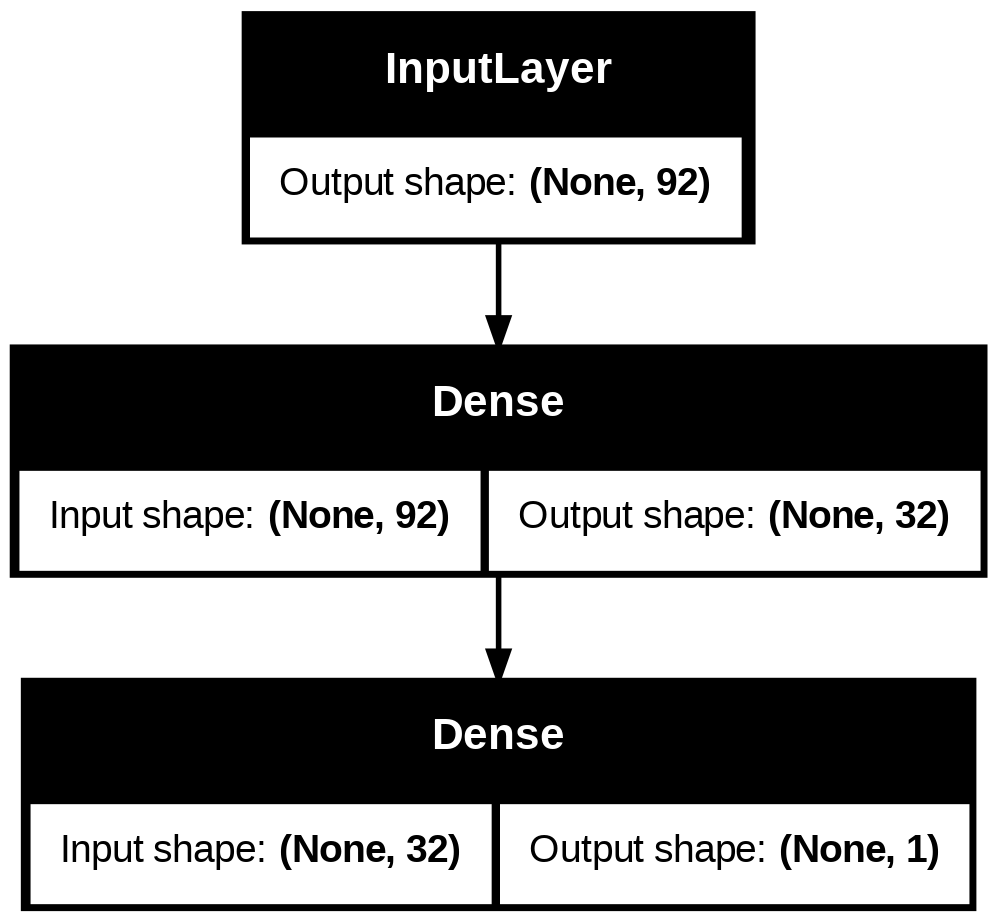

In [ ]:
keras.utils.plot_model(model, show_shapes=True)

In [ ]:
#optimizing
# loss function  is binary cross entroopy
#ptimizer used si adanm = accuracy metrics

In [ ]:
model.compile(loss="binary_crossentropy",
              optimizer="adam", metrics=["accuracy"])

In [ ]:
#train model
# minibatch size let 32 and epoch be 300

In [ ]:
history = model.fit(train_x, train_y,
                    epochs=300, batch_size=4096,
                    verbose = 1,
                    validation_split=0.2)

Epoch 1/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.7502 - loss: 0.6062 - val_accuracy: 0.6404 - val_loss: 0.6677
Epoch 2/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - accuracy: 0.9224 - loss: 0.4884 - val_accuracy: 0.8533 - val_loss: 0.5524
Epoch 3/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.9770 - loss: 0.3917 - val_accuracy: 0.9490 - val_loss: 0.4557
Epoch 4/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.9929 - loss: 0.3141 - val_accuracy: 0.9854 - val_loss: 0.3766
Epoch 5/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9966 - loss: 0.2527 - val_accuracy: 0.9921 - val_loss: 0.3128
Epoch 6/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step - accuracy: 0.9976 - loss: 0.2046 - val_accuracy: 0.9954 - val_loss: 0.2617
Epoch 7/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step - accuracy: 0.9979 - loss: 0.1670 - val_accuracy: 0.9962 - val_loss: 0.2207
Epoch 8/300
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step - accuracy: 0.9981 - loss: 0.1376 - val_accuracy: 0.9965 - val_loss:

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

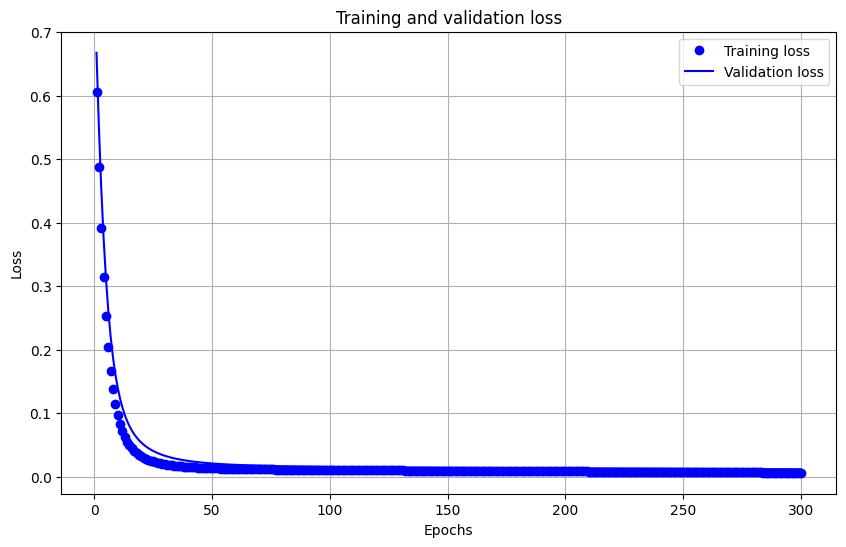

In [ ]:
loss = history_dict['loss']
val_loss = history_dict['val_loss']
epochs = range(1, len(loss) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, loss, 'bo', label='Training loss') # 'bo' for blue dots
plt.plot(epochs, val_loss, 'b', label='Validation loss') # 'b' for solid blue line
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

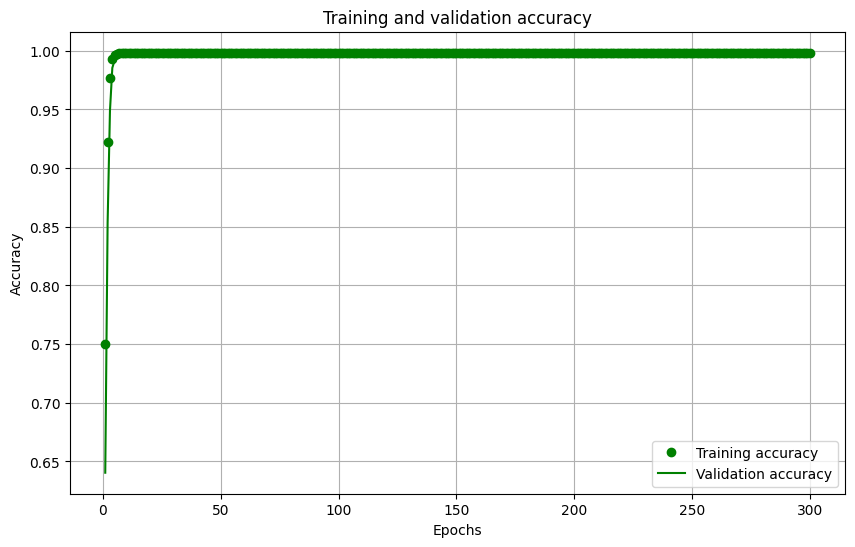

In [ ]:
acc = history_dict['accuracy']
val_acc = history_dict['val_accuracy']
epochs = range(1, len(acc) + 1)

plt.figure(figsize=(10, 6))
plt.plot(epochs, acc, 'go', label='Training accuracy') # 'go' for green dots
plt.plot(epochs, val_acc, 'g', label='Validation accuracy') # 'g' for solid green line
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
model.evaluate(test_x,test_y)

188/188 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9985 - loss: 0.0060


[0.005995145998895168, 0.9984999895095825]